# Monthly MISO event counts

Count monthly **MISO** P95 net-load event starts for six wind/solar portfolios over 2007–2023. The three panels retain events lasting at least 1, 6, and 12 hours; lines show the mean across years and shading shows P10–P90.

**Inputs:** the released direct-MISO BA stress-event catalog. Event durations already include its one-hour gap rule, documented in [the stress-event method](../data_flow/ba_stress_event_catalog.ipynb). This notebook uses the direct `MISO` region; the pairwise analysis uses `MISO_SUBREGION_SUM`.

**Requirements:** extract the historical Zenodo collection into `data_inputs/`.

**Outputs:** one embedded three-panel figure. No standalone files are written.

Run the code cells from top to bottom. See the [setup instructions](../../README.md#quick-start).

## Setup

In [1]:
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

# Point to the direct MISO BA event catalog and define the plot choices.
EVENT_PATH = Path(
    "../../data_inputs/wtk_bchrrr_nsrdb_2007_2023/ba_stress_event_catalog/"
    "MISO_wtk_bchrrr_nsrdb_2007_2023_events.csv"
).resolve()
P95 = 0.95
YEARS = list(range(2007, 2024))
MINIMUM_EVENT_HOURS = [1, 6, 12]
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
SCENARIOS = {
    "installed_2024": ("2024 Installed (70.3% Wind / 29.7% Solar)", "#111111"),
    "split_w00_s100": ("0% Wind / 100% Solar", "#E66101"),
    "split_w25_s75": ("25% Wind / 75% Solar", "#E6AB02"),
    "split_w50_s50": ("50% Wind / 50% Solar", "#1B9E77"),
    "split_w75_s25": ("75% Wind / 25% Solar", "#386CB0"),
    "split_w100_s00": ("100% Wind / 0% Solar", "#7B3294"),
}
assert EVENT_PATH.is_file(), f"Missing packaged input: {EVENT_PATH.as_posix()}"

# Shared presentation defaults; data values and plot limits are set below.
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "normal",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "legend.frameon": False,
        "grid.color": "#d1d5db",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.65,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    }
)

## Step 1: Load the event catalog

### Event definitions

- **P95:** One 95th-percentile net-load threshold is shared across all six MISO portfolios and all historical hours.
- **Portfolios:** Wind/solar percentages are shares of combined nameplate capacity.
- **Duration:** Isolated one-hour gaps below the threshold are bridged and included in event length. Cutoffs overlap: a 12-hour event counts in all three panels.
- **Months:** Each event is counted once per applicable panel, in its start month in UTC, even if it crosses a month boundary. Zero-event months contribute to the averages.
- **Shading:** P10–P90 shows variation in monthly counts across the 17 years, not uncertainty in the mean.

In [2]:
# Read only the columns needed to select and count events.
catalog = pd.read_csv(
    EVENT_PATH,
    usecols=["ba_code", "metric", "threshold_quantile", "event_start_utc", "event_length_hours"],
    parse_dates=["event_start_utc"],
)
metric_names = [f"net_load_mw__{scenario}" for scenario in SCENARIOS]
events = catalog.loc[
    catalog["ba_code"].eq("MISO")
    & catalog["threshold_quantile"].eq(P95)
    & catalog["metric"].isin(metric_names)
].copy()
events["scenario"] = events["metric"].str.removeprefix("net_load_mw__")

# Confirm the intended BA, portfolios, and historical period.
assert set(events["ba_code"]) == {"MISO"}
assert set(events["scenario"]) == set(SCENARIOS)
assert sorted(events["event_start_utc"].dt.year.unique()) == YEARS
print(f"Read {len(events):,} MISO P95 net-load events.\n  {EVENT_PATH.as_posix()}")

Read 8,016 MISO P95 net-load events.
  C:/Users/charl/OneDrive/Github/wxdata/paper_data/data/wtk_bchrrr_nsrdb_2007_2023/ba_stress_event_catalog/MISO_wtk_bchrrr_nsrdb_2007_2023_events.csv


## Step 2: Count events and summarize across years

In [3]:
# Count event starts by year and month for each duration cutoff.
events["year"] = events["event_start_utc"].dt.year
events["month"] = events["event_start_utc"].dt.month
monthly_parts = []

for minimum in MINIMUM_EVENT_HOURS:
    qualifying_events = events.loc[events["event_length_hours"].ge(minimum)]
    counts = qualifying_events.groupby(["scenario", "year", "month"]).size()
    counts = counts.reset_index(name="events")
    counts["minimum_event_hours"] = minimum
    monthly_parts.append(counts)

# Ensure months with zero events are included in the averages.
grid_names = ["scenario", "year", "month", "minimum_event_hours"]
complete_grid = pd.MultiIndex.from_product(
    [SCENARIOS, YEARS, range(1, 13), MINIMUM_EVENT_HOURS], names=grid_names
)
monthly_counts = pd.concat(monthly_parts)
monthly_counts = monthly_counts.set_index(grid_names)
monthly_counts = monthly_counts.reindex(complete_grid, fill_value=0)
monthly_counts = monthly_counts.reset_index()

# Calculate the monthly mean and P10–P90 range across 2007–2023.
groups = monthly_counts.groupby(["scenario", "month", "minimum_event_hours"])["events"]
monthly_mean = groups.mean().rename("mean")
monthly_summary = monthly_mean.to_frame()
monthly_summary["p10"] = groups.quantile(0.10)
monthly_summary["p90"] = groups.quantile(0.90)
monthly_summary = monthly_summary.reset_index()

assert len(monthly_counts) == len(SCENARIOS) * len(YEARS) * 12 * len(MINIMUM_EVENT_HOURS)
assert monthly_counts.loc[monthly_counts["minimum_event_hours"].eq(1), "events"].sum() == len(
    events
)
print("Monthly grid and event-total checks passed.")

Monthly grid and event-total checks passed.


## Step 3: Plot monthly counts

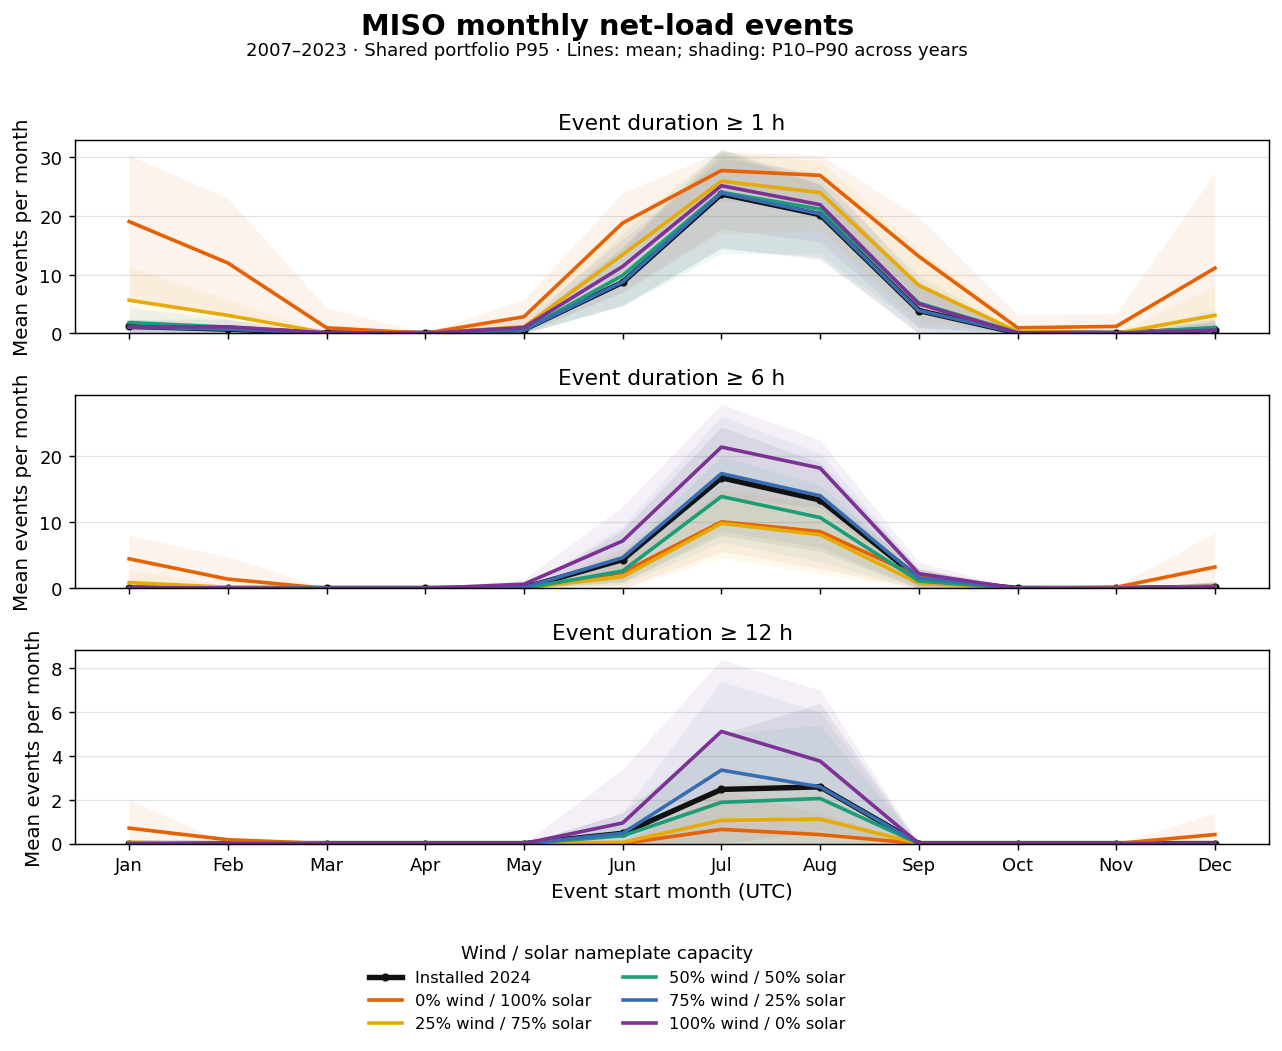

In [4]:
SCENARIO_LABELS = {
    "installed_2024": "Installed 2024",
    "split_w00_s100": "0% wind / 100% solar",
    "split_w25_s75": "25% wind / 75% solar",
    "split_w50_s50": "50% wind / 50% solar",
    "split_w75_s25": "75% wind / 25% solar",
    "split_w100_s00": "100% wind / 0% solar",
}

# Plot one panel for each minimum event duration.
fig, axes = plt.subplots(3, 1, figsize=(10.5, 8.2), sharex=True, dpi=130)
for axis, minimum in zip(axes, MINIMUM_EVENT_HOURS):
    panel = monthly_summary.loc[monthly_summary["minimum_event_hours"].eq(minimum)]
    for scenario, label in SCENARIO_LABELS.items():
        color = SCENARIOS[scenario][1]
        rows = panel.loc[panel["scenario"].eq(scenario)].sort_values("month")
        x = rows["month"].to_numpy()
        axis.fill_between(
            x,
            rows["p10"].to_numpy(),
            rows["p90"].to_numpy(),
            color=color,
            alpha=0.07,
            linewidth=0,
        )
        axis.plot(
            x,
            rows["mean"].to_numpy(),
            color=color,
            label=label,
            linewidth=3 if scenario == "installed_2024" else 2,
            marker="o" if scenario == "installed_2024" else None,
            markersize=3.5,
        )
    # Label the averages explicitly and use a zero baseline for each panel.
    axis.set(title=f"Event duration ≥ {minimum} h", ylabel="Mean events per month")
    axis.title.set_fontsize(12)
    axis.set_ylim(bottom=0)
    axis.grid(axis="y", color="#d1d5db", linewidth=0.7, alpha=0.65)
    axis.set_axisbelow(True)

axes[-1].set_xticks(range(1, 13), MONTHS)
axes[-1].set_xlabel("Event start month (UTC)")
fig.suptitle("MISO monthly net-load events", fontsize=16, fontweight="bold")
fig.text(
    0.5,
    0.94,
    "2007–2023 · Shared portfolio P95 · Lines: mean; shading: P10–P90 across years",
    ha="center",
    fontsize=10,
)
fig.legend(
    *axes[0].get_legend_handles_labels(),
    title="Wind / solar nameplate capacity",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=2,
    fontsize=9,
)
fig.subplots_adjust(left=0.11, right=0.985, bottom=0.20, top=0.86, hspace=0.32)
display(fig)
plt.close(fig)

## Interpretation

Longer-duration panels count subsets of the same events, so their counts cannot exceed the one-hour panel. Shading describes year-to-year variation; it is not a confidence interval for the mean.